# 🫁 Tuberculosis Detection from Chest X-rays using Deep Learning

### A Medical AI Project by Saket Gupta

I am **Saket Gupta**, a **3rd-year MBBS student at RNT Medical College, Udaipur**, with an interest in the intersection of **medicine, machine learning, and clinical AI**.

This project explores the use of **deep learning for the classification of chest X-ray images as Tuberculosis (TB) or Normal**. The model was developed using the **fastai deep learning framework** and is intended as a learning project to understand how computer vision can be applied to medical imaging.

> **Important:** This project is for educational and research-learning purposes only and is **not intended for clinical diagnosis or medical decision-making**.

## 📊 Dataset

The model uses the **Tuberculosis (TB) Chest X-ray Database** developed by researchers from **Qatar University, University of Dhaka, and collaborators**, in collaboration with medical doctors from Hamad Medical Corporation and Bangladesh.

The publicly accessible dataset contains:

- **700 TB-positive chest X-ray images**
- **3,500 Normal chest X-ray images**
- ### Dataset Citation

> T. Rahman, A. Khandakar, M. A. Kadir, K. R. Islam, K. F. Islam, Z. B. Mahbub, M. A. Ayari, and M. E. H. Chowdhury,  
> *"Reliable Tuberculosis Detection using Chest X-ray with Deep Learning, Segmentation and Visualization,"*  
> IEEE Access, vol. 8, pp. 191586–191601, 2020.  
> DOI: 10.1109/ACCESS.2020.3031384.


This cell counts the number of TB and Normal chest X-ray images in the dataset.

In [72]:
import os

tb_path = '/Users/akankshagupta/Desktop/TB ML model /TB_Chest_Radiography_Database/Tuberculosis'
normal_path = '/Users/akankshagupta/Desktop/TB ML model /TB_Chest_Radiography_Database/Normal'

print("TB images:", len(os.listdir(tb_path)))
print("Normal images:", len(os.listdir(normal_path)))

TB images: 700
Normal images: 3500


In [73]:
from PIL import Image
import matplotlib.pyplot as plt

Visualising the TB and Normal Images

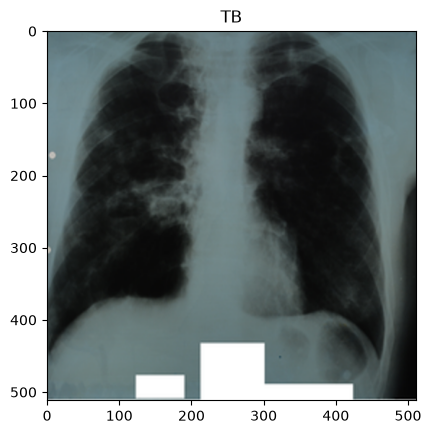

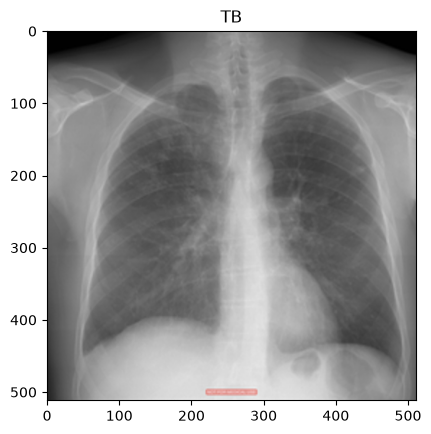

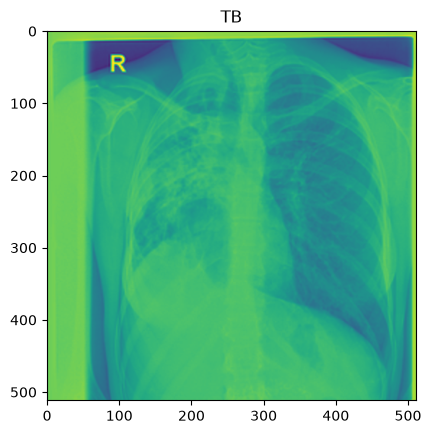

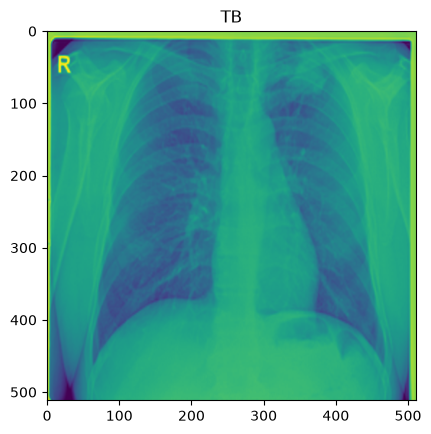

In [65]:
for x in os.listdir(tb_path)[:4]:
    img = Image.open(os.path.join(tb_path,x))
    plt.imshow(img)
    plt.title("TB")
    plt.show()

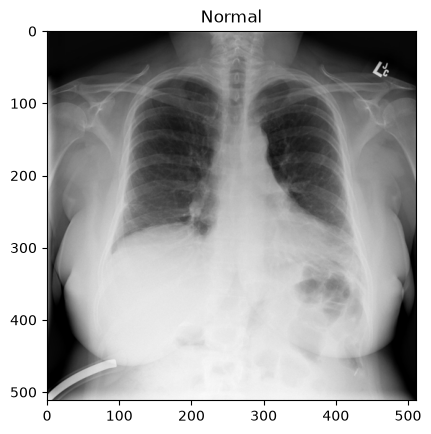

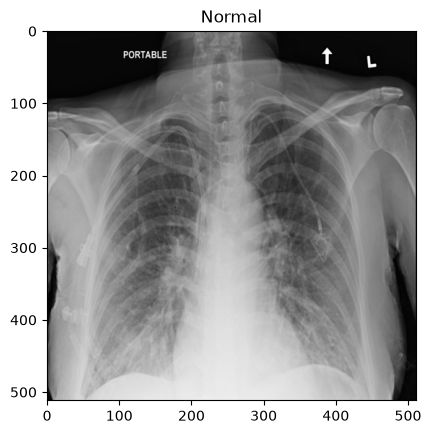

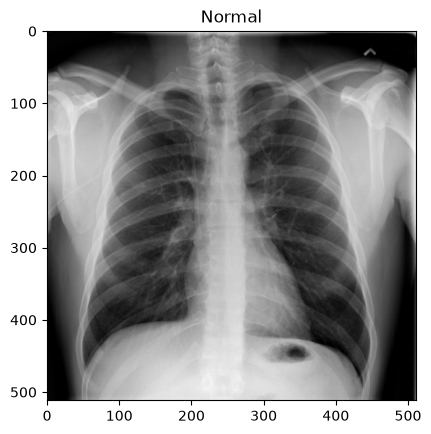

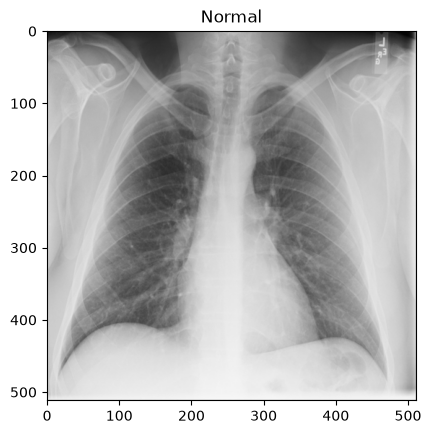

In [48]:
for x in os.listdir(normal_path)[:4]:
    img = Image.open(os.path.join(normal_path,x))
    plt.imshow(img)
    plt.title("Normal")
    plt.show()

### Creating the DataBlock
This cell defines how the images will be loaded, labeled, split into training and validation sets,resized to 224×224 pixels, and augmented before being given to the model.

In [53]:
from fastai.vision.all import *
from fastai.data import *

/Users/akankshagupta/ml-env/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [56]:
dblock = DataBlock(
    blocks= (ImageBlock , CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2 , seed = 42),
    get_y = parent_label,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms()
)

### Creating the DataLoaders

This cell provides the dataset path to the DataBlock and creates the DataLoaders that organize the images into batches for training and validation.

In [57]:
# DataLoders
path = Path('/Users/akankshagupta/Desktop/TB ML model /TB_Chest_Radiography_Database')
dls = dblock.dataloaders(path)

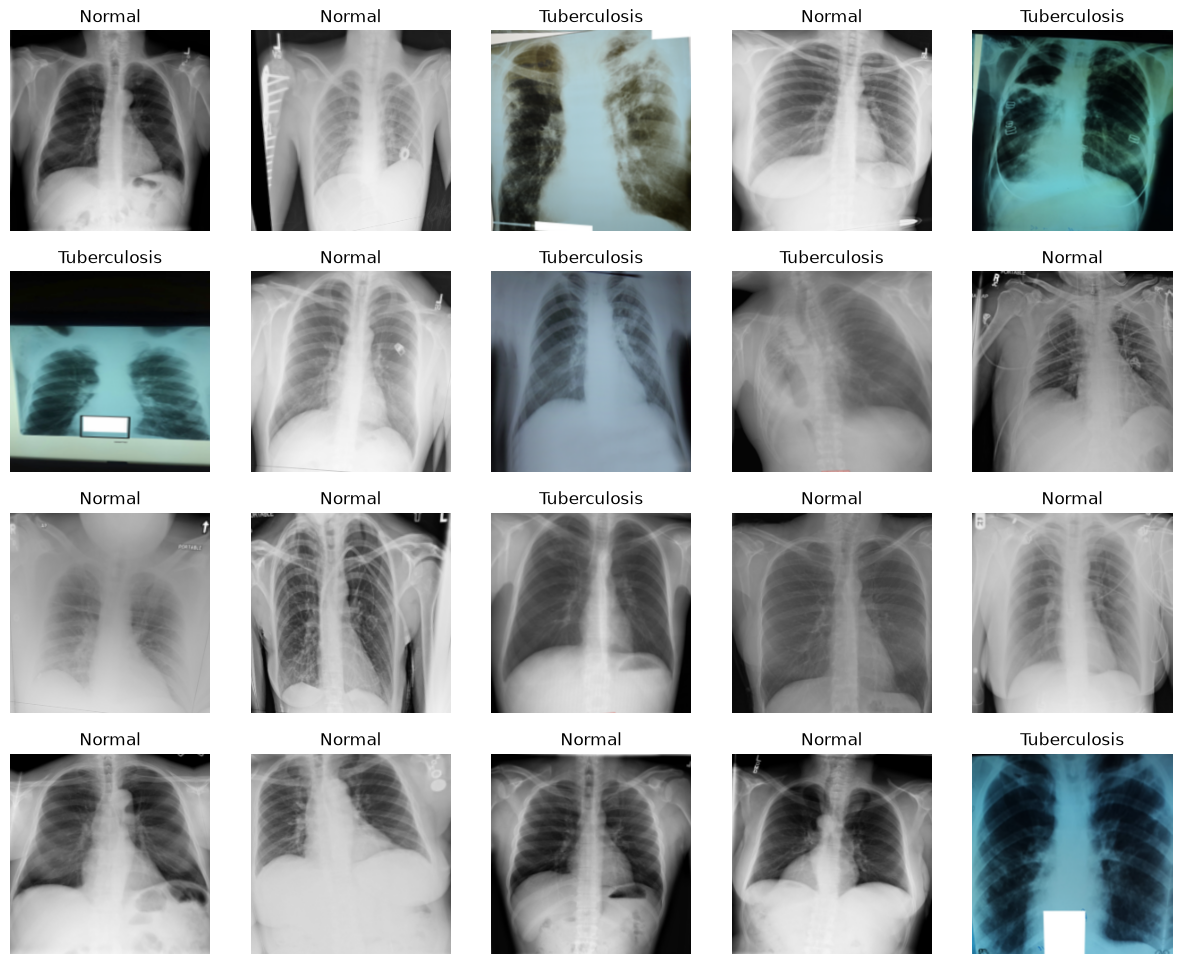

In [60]:
dls.show_batch(max_n = 20)

In [62]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)


epoch,train_loss,valid_loss,error_rate,time
0,0.501501,0.078844,0.029762,01:00


epoch,train_loss,valid_loss,error_rate,time
0,0.121733,0.020529,0.005952,01:12
1,0.078931,0.015693,0.003571,01:14
2,0.043392,0.014033,0.004762,01:14


### Model Training Results

The model achieved a final validation accuracy of **99.52%**, with a validation error rate of **0.48%** after 3 epochs of fine-tuning. The best validation accuracy observed was **99.64%**.

These results represent performance on the validation set and do not by themselves indicate clinical effectiveness. Further evaluation using a confusion matrix and additional metrics such as sensitivity and specificity is required.

## Checking the accuracy of our model 
 Create the interpretation object and plotting the confusion matrix, which guves us 700 true positive, 0 false positive,  

### Confusion Matrix

The confusion matrix shows that the model correctly classified **700 TB images** and **136 Normal images**. It produced **0 false positives** and **4 false negatives**.

This indicates that the model performed very well on the validation set. However, the **4 false negatives are particularly important in a TB screening task**, as these represent TB-positive images that were classified as Normal. Further evaluation using sensitivity, specificity, precision, and other clinically relevant metrics is therefore necessary.

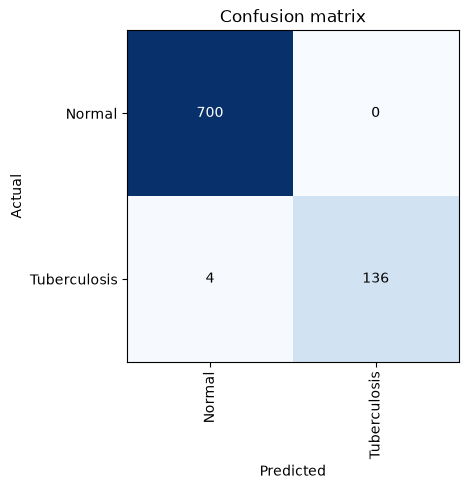

In [66]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

# Using other matrixes - Acuuracy , Specificity, sensitivity and precision 

In [74]:
TP = 136
TN = 700
FP = 0
FN = 4

accuracy = (TP + TN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP)

print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")

Accuracy: 0.9952
Sensitivity: 0.9714
Specificity: 1.0000
Precision: 1.0000
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# **Error Analysis**
**Viewing the top losses and most confused images by model**

In [76]:
interp.print_classification_report()

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       700
Tuberculosis       1.00      0.97      0.99       140

    accuracy                           1.00       840
   macro avg       1.00      0.99      0.99       840
weighted avg       1.00      1.00      1.00       840



In [69]:
interp.most_confused(min_val=2)

[('Tuberculosis', 'Normal', np.int64(4))]

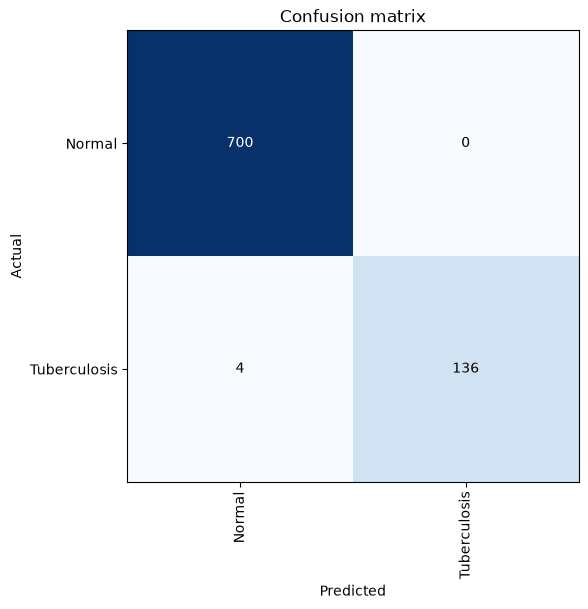

In [77]:
interp.plot_confusion_matrix(figsize=(6,6))

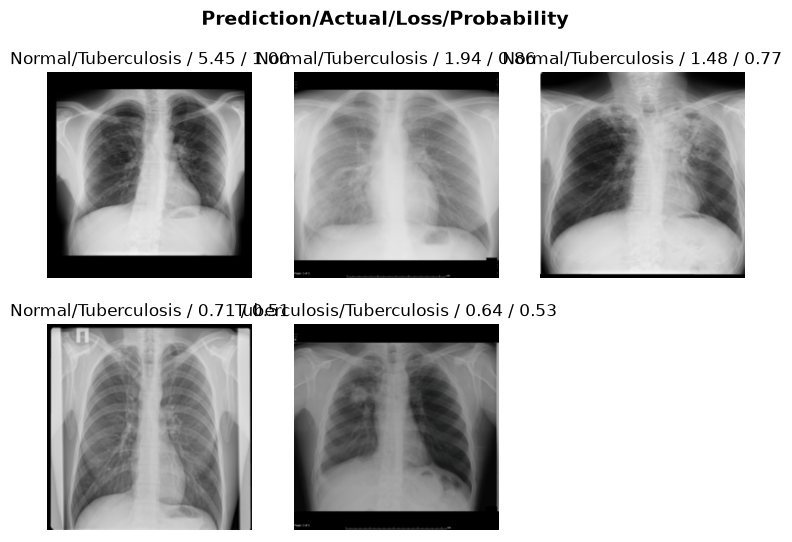

In [75]:
interp.plot_top_losses(k=5)

### Error Analysis Report

The top-loss images were examined to understand the cases where the model had the most difficulty. The validation set contained **4 false-negative predictions**, where TB images were classified as Normal.

The images did not show obvious image-quality or cropping problems on visual inspection. As a medical student, detailed radiological interpretation of these cases was not attempted. Instead, these misclassifications were recorded as examples of cases where the model may have difficulty and require further investigation.

# Trying the model on a completely new image

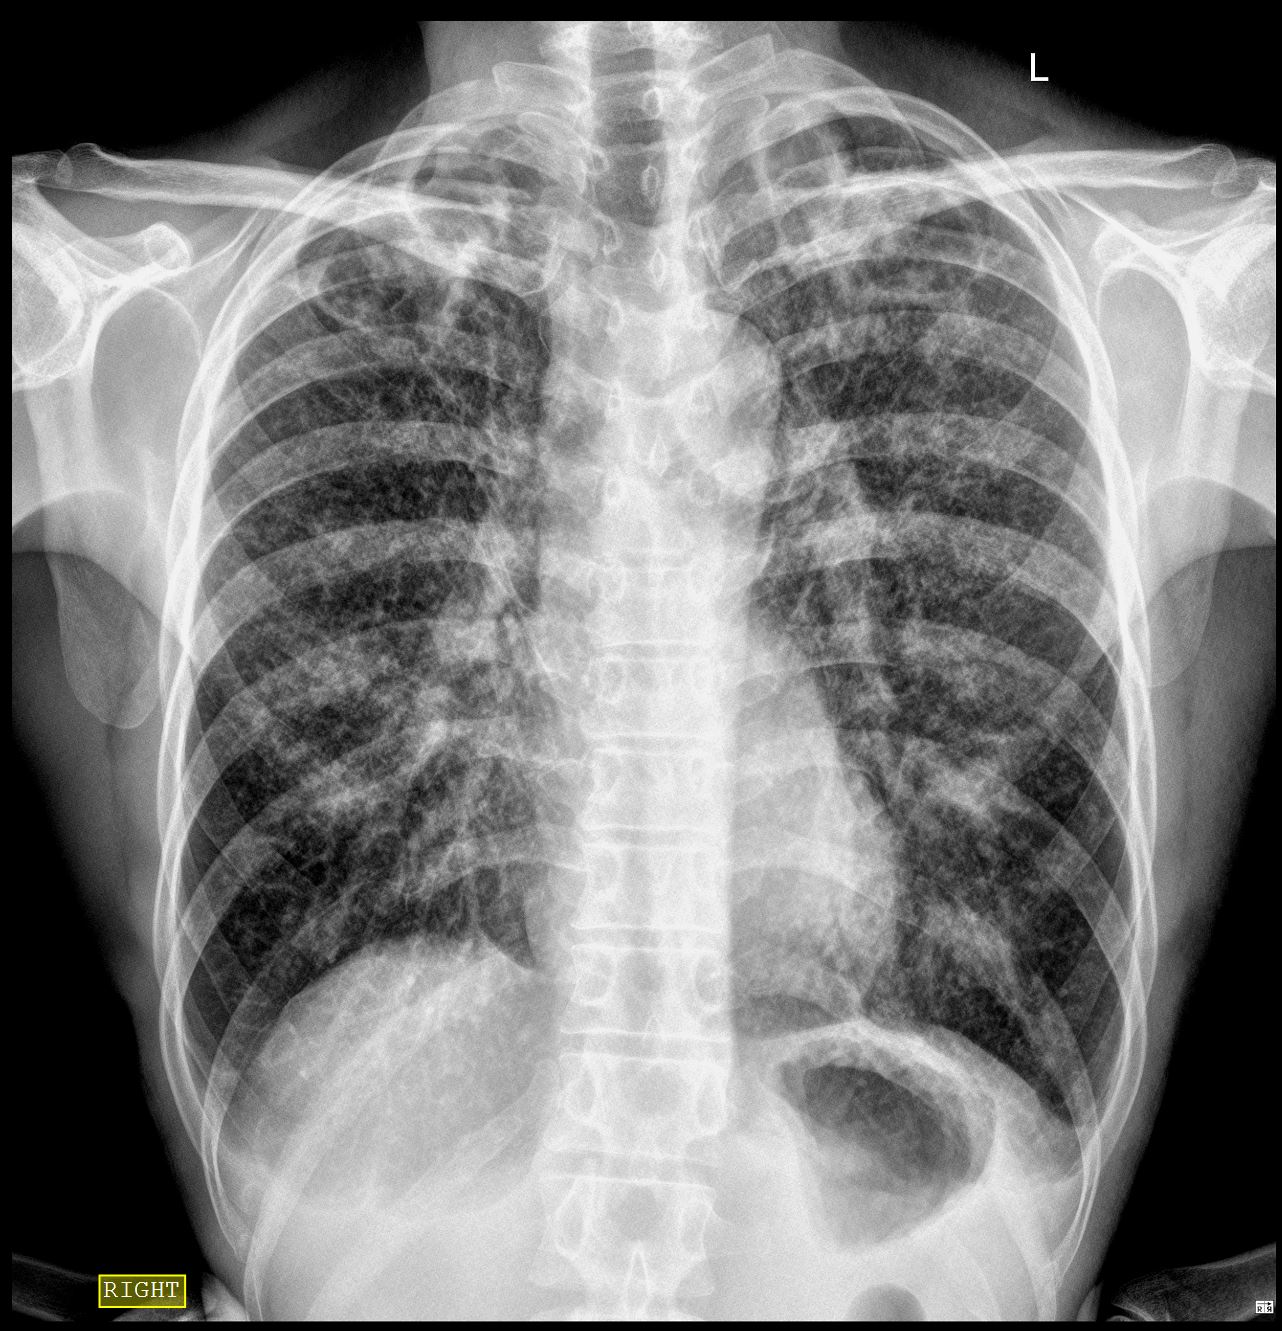

Prediction: Tuberculosis
Confidence: 0.6386697888374329


In [79]:
img = PILImage.create('/Users/akankshagupta/Desktop/TB ML model /pulmonary-tuberculosis-59.jpeg')

pred, pred_idx, probs = learn.predict(img)
display(img)
print("Prediction:", pred)
print("Confidence:", probs[pred_idx].item())



### Prediction on an External X-ray

To examine how the trained model behaves on an image outside the original dataset, a chest X-ray from **Radiopaedia** was used. The image source and citation were documented separately.

The model predicted **Tuberculosis** with a confidence of approximately **63.9%**.

This prediction was made on a single external image and should not be interpreted as a measure of model accuracy or clinical diagnostic performance. The lower confidence compared with the validation results highlights the importance of testing models on independent datasets from different sources before considering real-world applications.

**Citation** 
Case courtesy of Mohammad Osama Hussein Yonso, <a href="https://radiopaedia.org/?lang=us">Radiopaedia.org</a>. From the case <a href="https://radiopaedia.org/cases/96212?lang=us">rID: 96212</a>

# Limitations and Conclusion 
- The model was trained and evaluated on a specific publicly available dataset.
- Validation performance does not guarantee performance on other populations or hospitals.
- Only a single external image was used for an informal generalization demonstration.
- The model has not undergone clinical validation.
- False negatives remain important in a TB screening context.
- Further evaluation on independent datasets and expert-annotated data would be necessary.
- Model confidence drops on external image from different sources, indicating potential distribution shift.
  


**The project demonstrated an end-to-end deep-learning workflow for classifying chest X-rays as Tuberculosis or Normal using a ResNet18 model and fastai. The model achieved high performance on the validation split, while testing on an external image demonstrated that performance and confidence may differ on images from another source. This project served as an educational exploration of medical image classification and highlighted the importance of external validation and careful interpretation of model performance.**

In [84]:
learn.export("tb1_model.pkl")

In [85]:
learn.path

Path('.')